In [ ]:
from pathlib import Path

DATA_DIR  = Path('path_to_preprocessed_data')
TRAIN_DIR = DATA_DIR / 'train'
VALID_DIR = DATA_DIR / 'valid'
TEST_DIR = DATA_DIR / 'test'
NOISE_DIR = DATA_DIR / '_background_noise_'

print("Train:", len(list(TRAIN_DIR.rglob('*.wav'))))
print("Valid:", len(list(VALID_DIR.rglob('*.wav'))))


Train: 51486
Valid: 6828


In [ ]:
import sys, os
REPO_PATH = 'path_to_repo'
sys.path.insert(0, REPO_PATH)
os.chdir(REPO_PATH) 

import torch
import numpy as np
from data.utils import get_datasets, precompute_features
from data.dataset import CachedDataset
from data.transforms import FeatureConfig
from models.train import train, predict
from models.evaluate import evaluate
from models.cnn import CNN
from models.transformer import Transformer
from models.cnn_transformer import CNNTransformer
from models.utils import set_seed
from models.evaluate import evaluate
from plots import plot_f1_training_curves, build_summary_df, plot_summary_table, plot_metrics_comparison, plot_f1_comparison, plot_confusion_matrix

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print('Using device:', device)

Using device: cuda


In [3]:
SEEDS = [0, 1, 2]
EPOCHS = 30
BATCH_SIZE = 64
LR = 3e-4
REPRESENTATIONS = ['mfcc', 'mel']

#### Data Representation - MFCC vs Mel Spectrogram


- **MFCC** (`mfcc` format): 40 coefficients, normalized
- **Mel Spectrogram** (`mel` format): 64 mel bins, normalized


In [4]:
train_ds_mfcc, valid_ds_mfcc, test_ds_mfcc = get_datasets(data_format='mfcc', train_path=TRAIN_DIR, valid_path=VALID_DIR, test_path=TEST_DIR)
precompute_features(train_ds_mfcc, Path('/kaggle/working/cache/train_mfcc'))
precompute_features(valid_ds_mfcc, Path('/kaggle/working/cache/valid_mfcc'))
precompute_features(test_ds_mfcc, Path('/kaggle/working/cache/test_mfcc'))
train_ds_mfcc_cached = CachedDataset('/kaggle/working/cache/train_mfcc')
valid_ds_mfcc_cached = CachedDataset('/kaggle/working/cache/valid_mfcc')
test_ds_mfcc_cached = CachedDataset('/kaggle/working/cache/test_mfcc')

  0%|          | 0/51486 [00:00<?, ?it/s]

Saved 51486 samples to /kaggle/working/cache/train_mfcc


  0%|          | 0/6828 [00:00<?, ?it/s]

Saved 6828 samples to /kaggle/working/cache/valid_mfcc


  0%|          | 0/6865 [00:00<?, ?it/s]

Saved 6865 samples to /kaggle/working/cache/test_mfcc


In [6]:
train_ds_mel, valid_ds_mel, test_ds_mel = get_datasets(data_format='mel', train_path=TRAIN_DIR, valid_path=VALID_DIR, test_path=TEST_DIR)
precompute_features(train_ds_mel, Path('/kaggle/working/cache/train_mel'))
precompute_features(valid_ds_mel, Path('/kaggle/working/cache/valid_mel'))
precompute_features(test_ds_mel, Path('/kaggle/working/cache/test_mel'))
train_ds_mel_cached = CachedDataset('/kaggle/working/cache/train_mel')
valid_ds_mel_cached = CachedDataset('/kaggle/working/cache/valid_mel')
test_ds_mel_cached = CachedDataset('/kaggle/working/cache/test_mel')

  0%|          | 0/51486 [00:00<?, ?it/s]

Saved 51486 samples to /kaggle/working/cache/train_mel


  0%|          | 0/6828 [00:00<?, ?it/s]

Saved 6828 samples to /kaggle/working/cache/valid_mel


  0%|          | 0/6865 [00:00<?, ?it/s]

Saved 6865 samples to /kaggle/working/cache/test_mel


In [7]:
def run_representation_experiment(model_factory, representations, seeds, epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR, device=device, model_name='Model'):
    """
    Train `model_factory(repr)` for every representation x seed combination.

    Args:
        model_factory: callable(repr_str) -> nn.Module  (already moved to device)
        representations: list of str, e.g. ['mfcc', 'mel']
        seeds: list of int
        ...

    Returns:
        results dict with structure:
            results[repr][seed] = {
                'history': training history dict,
                'valid_acc': float,
                'valid_loss': float,
                'valid_f1': float,
                'test_acc': float,
                'test_loss': float,
                'test_macro_f1': float,
                'test_weighted_f1': float,
                'test_cm': np.array,
            }
    """
    
    results = {}

    for repr_name in representations:
        results[repr_name] = {}

        if repr_name == 'mfcc':
            train_ds_cached = train_ds_mfcc_cached
            valid_ds_cached = valid_ds_mfcc_cached
            test_ds_cached = test_ds_mfcc_cached
        elif repr_name == 'mel':
            train_ds_cached = train_ds_mel_cached
            valid_ds_cached = valid_ds_mel_cached
            test_ds_cached = test_ds_mel_cached
        else:
            raise ValueError('Unknown representation.')

        for seed in seeds:
            print(f'\n[{model_name}] repr={repr_name} | seed={seed}')
            print('-' * 55)
            set_seed(seed)

            model = model_factory(repr_name).to(device)
            model, history = train(model, train_ds_cached, valid_ds_cached, epochs=epochs, batch_size=batch_size, lr=lr,
                device=str(device), verbose=True, verbose_interval=5)

            valid_acc = history['valid_acc'][-1]
            valid_loss = history['valid_loss'][-1]

            preds, labels = predict(model, test_ds_cached, device=str(device), batch_size=batch_size)
            test_results = evaluate(preds, labels, print_report=False)
            test_acc = test_results['acc']

            results[repr_name][seed] = {
                'history': history,
                'valid_acc': valid_acc,
                'valid_loss': valid_loss,
                'valid_f1': history['valid_f1'][-1],
                'test_acc': test_results['acc'],
                'test_macro_f1': test_results['macro_f1'],
                'test_weighted_f1': test_results['weighted_f1'],
                'test_cm': test_results['cm'],
            }

    return results

### CNN

In [29]:
def cnn_factory(repr_name):
    """Return a CNN configured for the given representation."""
    # mfcc -> [1, 40, T]  |  mel -> [1, 64, T]
    return CNN(num_classes=12, in_channels=1, base_channels=32, dropout=0.3)

cnn_results = run_representation_experiment(model_factory=cnn_factory, representations=REPRESENTATIONS, seeds=SEEDS, model_name='CNN')


[CNN] repr=mfcc | seed=0
-------------------------------------------------------
Epoch 5/30 | Train Loss: 0.5232 | Valid Loss: 0.4359 | Valid Acc: 0.8852 | Valid Macro F1: 0.8197
Epoch 10/30 | Train Loss: 0.3482 | Valid Loss: 0.4933 | Valid Acc: 0.8490 | Valid Macro F1: 0.8008
Epoch 15/30 | Train Loss: 0.2776 | Valid Loss: 0.2862 | Valid Acc: 0.9142 | Valid Macro F1: 0.8682
Epoch 20/30 | Train Loss: 0.2390 | Valid Loss: 0.3103 | Valid Acc: 0.9095 | Valid Macro F1: 0.8715
Epoch 25/30 | Train Loss: 0.2150 | Valid Loss: 0.2303 | Valid Acc: 0.9328 | Valid Macro F1: 0.9018
Epoch 30/30 | Train Loss: 0.2090 | Valid Loss: 0.2239 | Valid Acc: 0.9344 | Valid Macro F1: 0.9051
Best validation accuracy: 0.9344

[CNN] repr=mfcc | seed=1
-------------------------------------------------------
Epoch 5/30 | Train Loss: 0.5423 | Valid Loss: 0.5623 | Valid Acc: 0.8360 | Valid Macro F1: 0.7321
Epoch 10/30 | Train Loss: 0.3578 | Valid Loss: 0.3637 | Valid Acc: 0.8934 | Valid Macro F1: 0.8326
Epoch 15/30 |

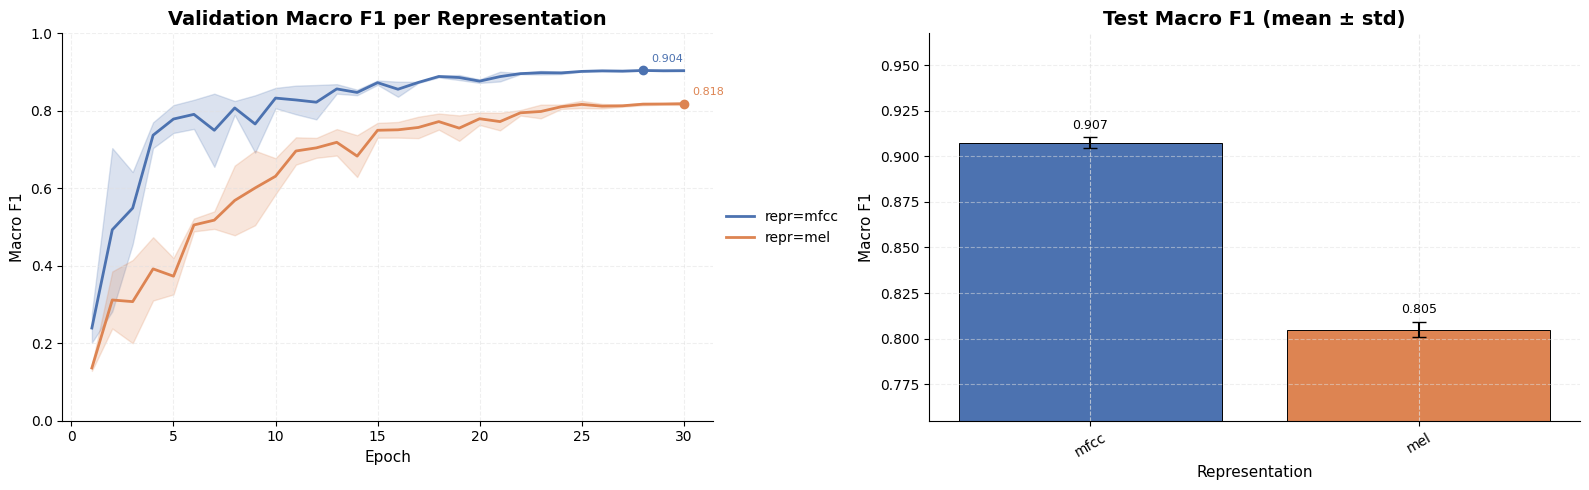

In [30]:
plot_f1_comparison(cnn_results, param_name='Representation', param_name_short='repr')

In [31]:
summary_cnn = build_summary_df({
    'CNN': cnn_results
})
plot_summary_table(summary_cnn)

,Model,Representation,Test Acc,Test Acc CV,Macro F1,Macro F1 CV,Weighted F1,Weighted F1 CV
0,CNN,mfcc,0.9371 ± 0.0013,0.001,0.9074 ± 0.0031,0.003,0.9365 ± 0.0015,0.002
1,CNN,mel,0.8721 ± 0.0016,0.002,0.8050 ± 0.0042,0.005,0.8652 ± 0.0019,0.002


,Model,Representation,Test Acc,Test Acc CV,Macro F1,Macro F1 CV,Weighted F1,Weighted F1 CV
0,CNN,mfcc,0.9371 ± 0.0013,0.001,0.9074 ± 0.0031,0.003,0.9365 ± 0.0015,0.002
1,CNN,mel,0.8721 ± 0.0016,0.002,0.8050 ± 0.0042,0.005,0.8652 ± 0.0019,0.002


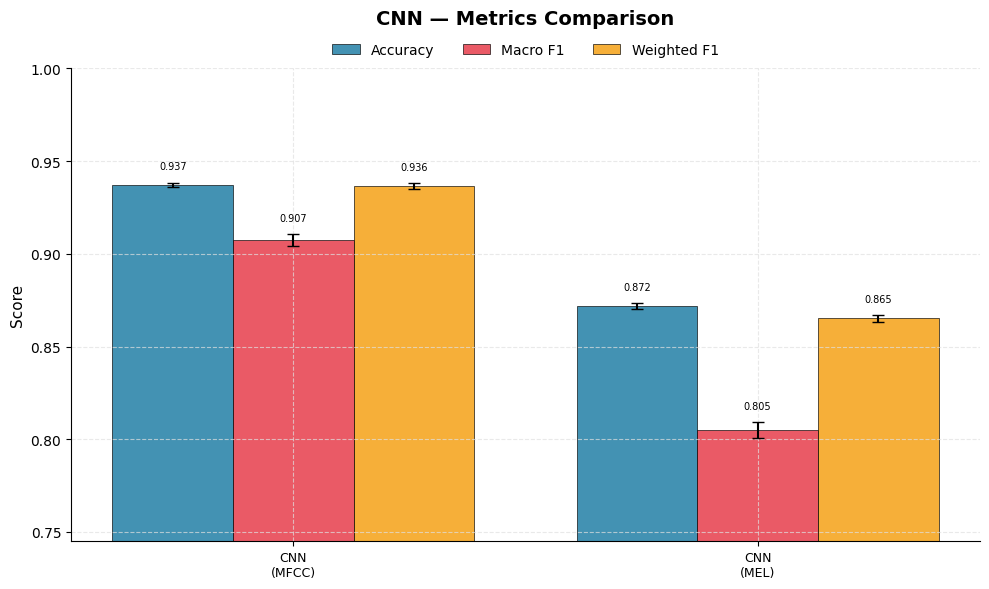

In [32]:
plot_metrics_comparison(summary_cnn, title='CNN — Metrics Comparison')

best_repr: mfcc, best_seed: 2 


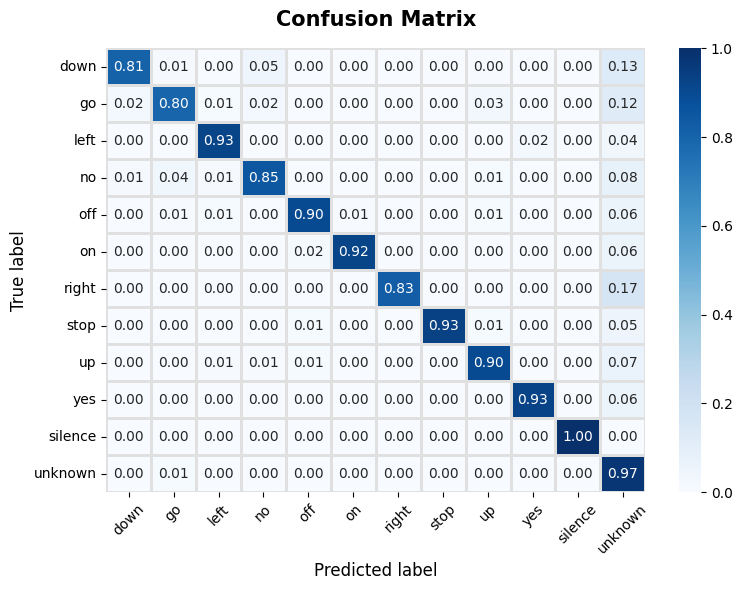

In [33]:
best_repr = max(cnn_results, key=lambda r: np.mean([v['test_macro_f1'] for v in cnn_results[r].values()]))
best_seed = max(cnn_results[best_repr], key=lambda s: cnn_results[best_repr][s]['test_macro_f1'])
print(f"best_repr: {best_repr}, best_seed: {best_seed} ")
best_result = cnn_results[best_repr][best_seed]
plot_confusion_matrix(best_result['test_cm'])


### Transformer

In [34]:
def transformer_factory(repr_name):
    n_features = 40 if repr_name == 'mfcc' else 64
    return Transformer(n_features=n_features, n_timesteps=101, num_classes=12, d_model=128, nhead=4, num_layers=4, dropout=0.1, pooling='mean')

transformer_results = run_representation_experiment(model_factory=transformer_factory, representations=REPRESENTATIONS, seeds=SEEDS, model_name='Transformer')


[Transformer] repr=mfcc | seed=0
-------------------------------------------------------
Epoch 5/30 | Train Loss: 0.1423 | Valid Loss: 0.2101 | Valid Acc: 0.9329 | Valid Macro F1: 0.8917
Epoch 10/30 | Train Loss: 0.0697 | Valid Loss: 0.1984 | Valid Acc: 0.9461 | Valid Macro F1: 0.9200
Epoch 15/30 | Train Loss: 0.0432 | Valid Loss: 0.1972 | Valid Acc: 0.9501 | Valid Macro F1: 0.9249
Epoch 20/30 | Train Loss: 0.0226 | Valid Loss: 0.2176 | Valid Acc: 0.9547 | Valid Macro F1: 0.9332
Epoch 25/30 | Train Loss: 0.0132 | Valid Loss: 0.2420 | Valid Acc: 0.9531 | Valid Macro F1: 0.9300
Epoch 30/30 | Train Loss: 0.0098 | Valid Loss: 0.2412 | Valid Acc: 0.9547 | Valid Macro F1: 0.9319
Best validation accuracy: 0.9588

[Transformer] repr=mfcc | seed=1
-------------------------------------------------------
Epoch 5/30 | Train Loss: 0.1431 | Valid Loss: 0.1929 | Valid Acc: 0.9445 | Valid Macro F1: 0.9177
Epoch 10/30 | Train Loss: 0.0741 | Valid Loss: 0.1933 | Valid Acc: 0.9464 | Valid Macro F1: 0.91

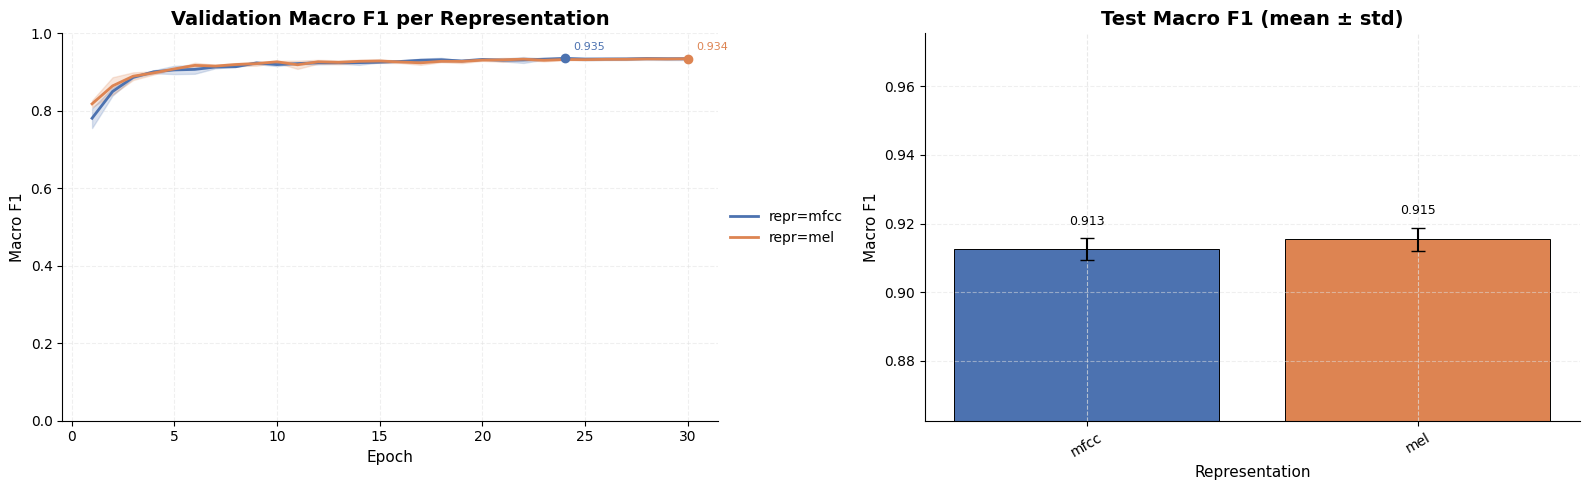

In [38]:
plot_f1_comparison(transformer_results, param_name='Representation', param_name_short='repr')

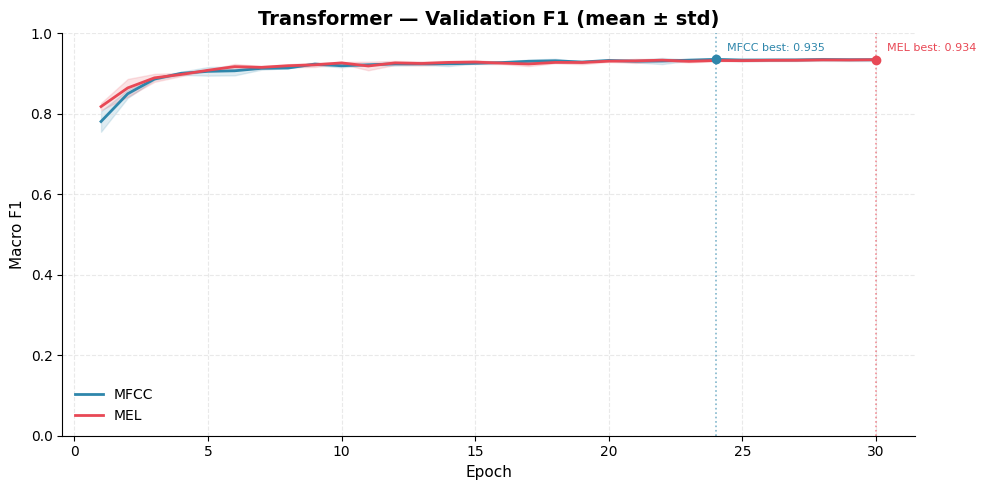

In [35]:
plot_f1_training_curves(transformer_results, title_prefix='Transformer')

In [36]:
summary_transformer = build_summary_df({
    'Transformer': transformer_results
})
plot_summary_table(summary_transformer)

,Model,Representation,Test Acc,Test Acc CV,Macro F1,Macro F1 CV,Weighted F1,Weighted F1 CV
0,Transformer,mfcc,0.9608 ± 0.0003,0.000,0.9126 ± 0.0031,0.003,0.9617 ± 0.0007,0.001
1,Transformer,mel,0.9588 ± 0.0016,0.002,0.9154 ± 0.0034,0.004,0.9594 ± 0.0020,0.002


,Model,Representation,Test Acc,Test Acc CV,Macro F1,Macro F1 CV,Weighted F1,Weighted F1 CV
0,Transformer,mfcc,0.9608 ± 0.0003,0.000,0.9126 ± 0.0031,0.003,0.9617 ± 0.0007,0.001
1,Transformer,mel,0.9588 ± 0.0016,0.002,0.9154 ± 0.0034,0.004,0.9594 ± 0.0020,0.002


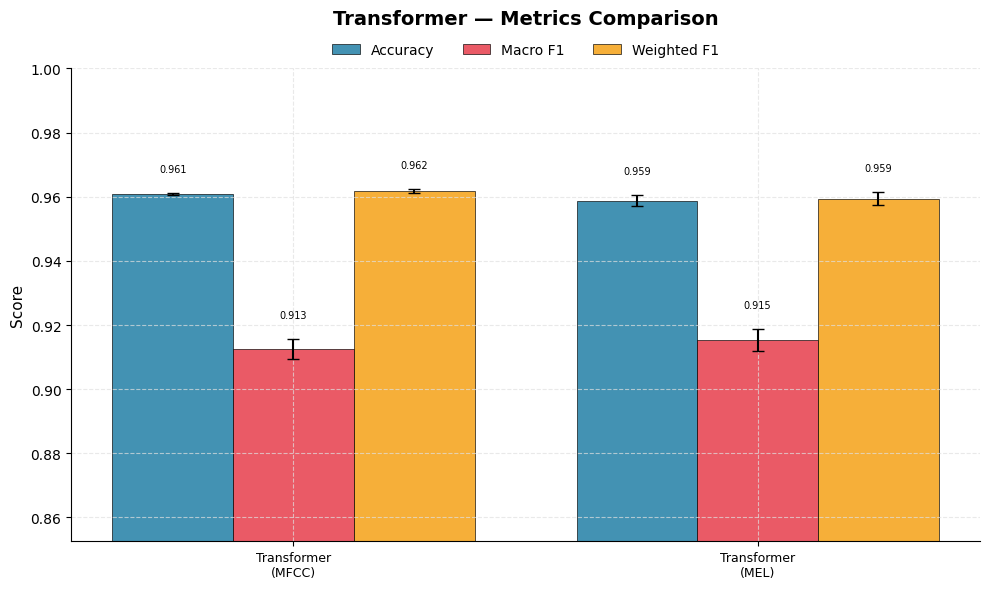

In [37]:
plot_metrics_comparison(summary_transformer, title='Transformer — Metrics Comparison')

best_repr: mel, best_seed: 1 


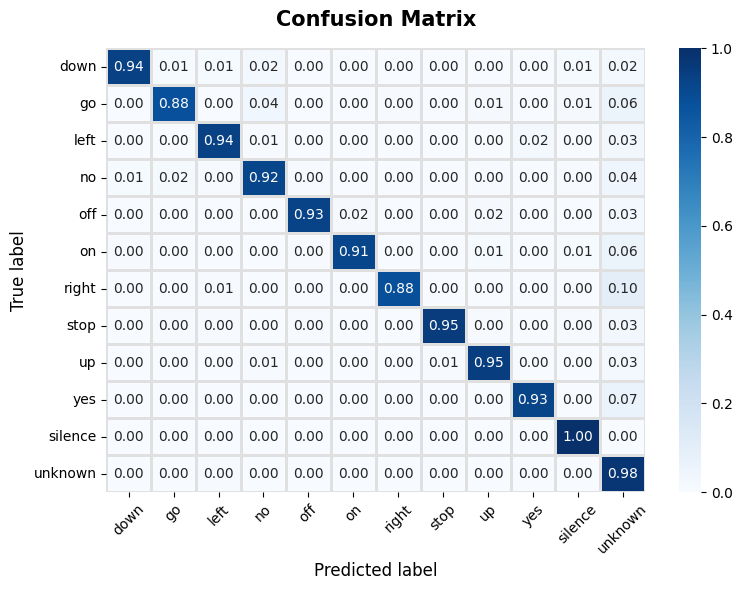

In [39]:
best_repr = max(transformer_results, key=lambda r: np.mean([v['test_macro_f1'] for v in transformer_results[r].values()]))
best_seed = max(transformer_results[best_repr], key=lambda s: transformer_results[best_repr][s]['test_macro_f1'])
print(f"best_repr: {best_repr}, best_seed: {best_seed} ")
best_result = transformer_results[best_repr][best_seed]
plot_confusion_matrix(best_result['test_cm'])

### CNN + Transformer

In [8]:
def cnn_transformer_factory(repr_name):
    n_features = 40 if repr_name == 'mfcc' else 64
    return CNNTransformer(n_features=n_features, n_timesteps=101, num_classes=12, base_channels=32, d_model=128, nhead=4, num_layers=4, dropout=0.1, pooling='mean')

cnn_transformer_results = run_representation_experiment(model_factory=cnn_transformer_factory, representations=REPRESENTATIONS, seeds=SEEDS, model_name='CNNTransformer')


[CNNTransformer] repr=mfcc | seed=0
-------------------------------------------------------
Epoch 5/30 | Train Loss: 0.1069 | Valid Loss: 0.1656 | Valid Acc: 0.9495 | Valid Macro F1: 0.9203
Epoch 10/30 | Train Loss: 0.0606 | Valid Loss: 0.1730 | Valid Acc: 0.9515 | Valid Macro F1: 0.9284
Epoch 15/30 | Train Loss: 0.0346 | Valid Loss: 0.1653 | Valid Acc: 0.9610 | Valid Macro F1: 0.9417
Epoch 20/30 | Train Loss: 0.0185 | Valid Loss: 0.1891 | Valid Acc: 0.9613 | Valid Macro F1: 0.9425
Epoch 25/30 | Train Loss: 0.0061 | Valid Loss: 0.2229 | Valid Acc: 0.9605 | Valid Macro F1: 0.9419
Epoch 30/30 | Train Loss: 0.0020 | Valid Loss: 0.2384 | Valid Acc: 0.9605 | Valid Macro F1: 0.9414
Best validation accuracy: 0.9616

[CNNTransformer] repr=mfcc | seed=1
-------------------------------------------------------
Epoch 5/30 | Train Loss: 0.1091 | Valid Loss: 0.1866 | Valid Acc: 0.9452 | Valid Macro F1: 0.9198
Epoch 10/30 | Train Loss: 0.0561 | Valid Loss: 0.1648 | Valid Acc: 0.9571 | Valid Macro F1

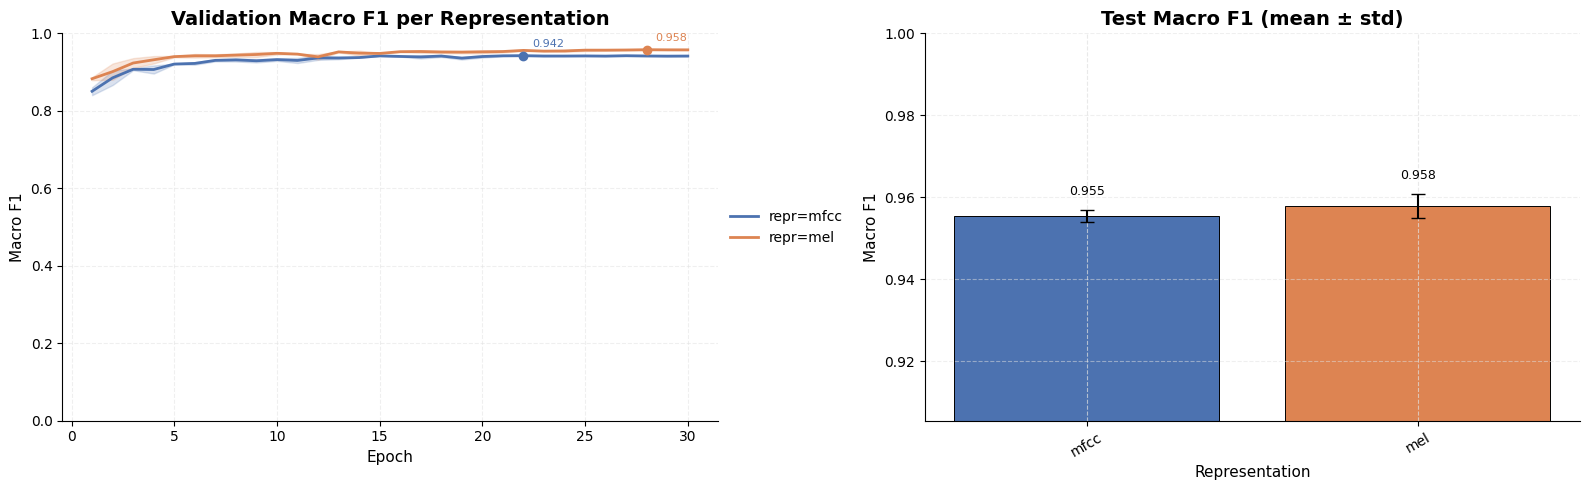

In [13]:
plot_f1_comparison(cnn_transformer_results, param_name='Representation', param_name_short='repr')

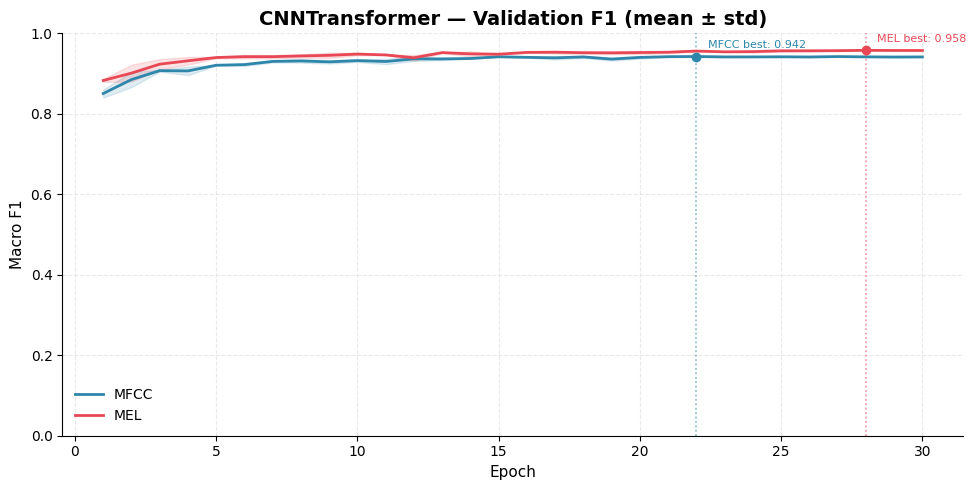

In [9]:
plot_f1_training_curves(cnn_transformer_results, title_prefix='CNNTransformer')

In [10]:
summary_cnn_transformer = build_summary_df({
    'CNNTransformer': cnn_transformer_results
})

In [11]:
plot_summary_table(summary_cnn_transformer)

,Model,Representation,Test Acc,Test Acc CV,Macro F1,Macro F1 CV,Weighted F1,Weighted F1 CV
0,CNNTransformer,mfcc,0.9690 ± 0.0008,0.001,0.9554 ± 0.0014,0.001,0.9688 ± 0.0009,0.001
1,CNNTransformer,mel,0.9739 ± 0.0006,0.001,0.9579 ± 0.0029,0.003,0.9738 ± 0.0006,0.001


,Model,Representation,Test Acc,Test Acc CV,Macro F1,Macro F1 CV,Weighted F1,Weighted F1 CV
0,CNNTransformer,mfcc,0.9690 ± 0.0008,0.001,0.9554 ± 0.0014,0.001,0.9688 ± 0.0009,0.001
1,CNNTransformer,mel,0.9739 ± 0.0006,0.001,0.9579 ± 0.0029,0.003,0.9738 ± 0.0006,0.001


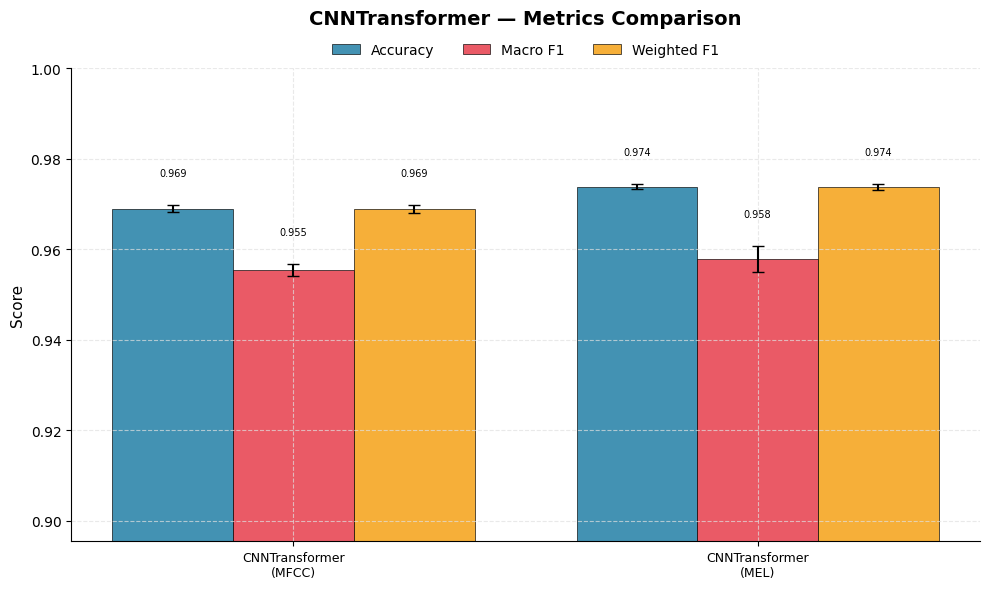

In [12]:
plot_metrics_comparison(summary_cnn_transformer, title='CNNTransformer — Metrics Comparison')

best_repr: mel, best_seed: 1 


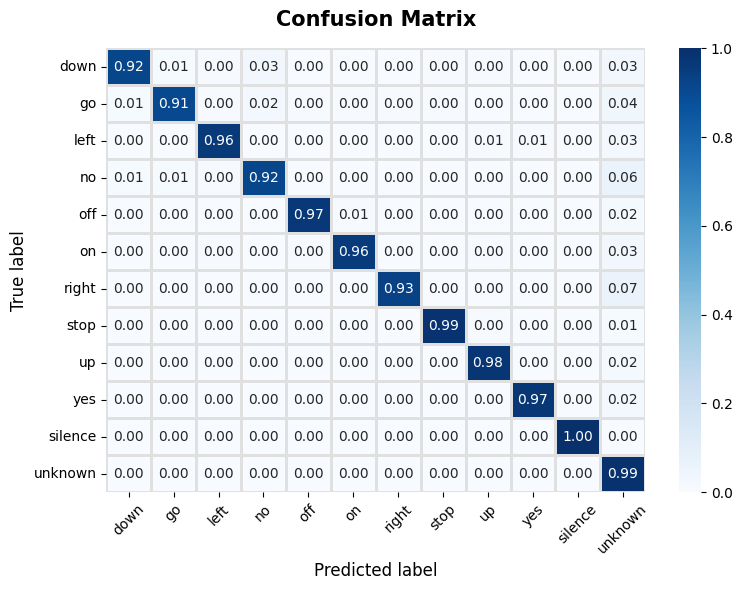

In [14]:
best_repr = max(cnn_transformer_results, key=lambda r: np.mean([v['test_macro_f1'] for v in cnn_transformer_results[r].values()]))
best_seed = max(cnn_transformer_results[best_repr], key=lambda s: cnn_transformer_results[best_repr][s]['test_macro_f1'])
print(f"best_repr: {best_repr}, best_seed: {best_seed} ")
best_result = cnn_transformer_results[best_repr][best_seed]
plot_confusion_matrix(best_result['test_cm'])